In [83]:
from pathlib import Path

import numpy as np
import pandas as pd
import datetime as dt

from scipy.optimize import minimize, brentq
from scipy.special import expit, logit, gammaln, gamma
from scipy.stats import probplot, norm, poisson, nbinom, uniform, genextreme

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import seaborn as sns

HarveyGEV
│
├── _standardized_residual()
│
├── pdf()
├── logpdf()
│
├── score() -> não padronizazdo
├── fisher_information()
│
├── score_derivative() -> padronizado
├── find_c()
├── find_d()
├── composite_score() -> padronizado
│
├── filter()
│
├── loglikelihood()
├── negative_loglikelihood()
│
└── fit()

In [2]:
def _standardized_residual(y, mu, varphi):
    """
    Calcula o resíduo padronizado:

        x_t = (y_t - mu_{t|t-1}) / varphi

    Parameters
    ----------
    y : float or np.ndarray
        Observação(ões) y_t.
    mu : float or np.ndarray
        Localização condicional mu_{t|t-1}.
    varphi : float
        Parâmetro de escala, varphi > 0.

    Returns
    -------
    x : float or np.ndarray
        Resíduo padronizado x_t.
    """
    return (y - mu) / varphi

In [5]:
def pdf(y, mu, varphi, xi):
    """
    Densidade GEV condicional.

    Parameters
    ----------
    y : float or np.ndarray
        Observação(ões) y_t.
    mu : float or np.ndarray
        Localização condicional mu_{t|t-1}.
    varphi : float
        Parâmetro de escala, varphi > 0.
    xi : float
        Parâmetro de forma.

    Returns
    -------
    p : float or np.ndarray
        Densidade condicional.
    """
    x = _standardized_residual(y, mu, varphi)

    if xi != 0:
        z = 1 + xi * x

        if np.any(z <= 0):
            return 0.0

        return (
            (1 / varphi)
            * z ** (-1 - 1 / xi)
            * np.exp(-z ** (-1 / xi))
        )

    else:
        return (
            (1 / varphi)
            * np.exp(-x)
            * np.exp(-np.exp(-x))
        )

In [6]:
def logpdf(y, mu, varphi, xi):
    """
    Log-densidade GEV condicional.

    Parameters
    ----------
    y : float or np.ndarray
        Observação(ões) y_t.
    mu : float or np.ndarray
        Localização condicional mu_{t|t-1}.
    varphi : float
        Parâmetro de escala, varphi > 0.
    xi : float
        Parâmetro de forma.

    Returns
    -------
    log_p : float or np.ndarray
        Log-densidade condicional.
    """
    x = _standardized_residual(y, mu, varphi)

    if xi != 0:
        z = 1 + xi * x

        if np.any(z <= 0):
            return -np.inf

        return (
            -np.log(varphi)
            - (1 + 1 / xi) * np.log(z)
            - z ** (-1 / xi)
        )

    else:
        return (
            -np.log(varphi)
            - x
            - np.exp(-x)
        )

In [57]:
def score(y, xi, mu=0, varphi=1):
    """
    Score da log-densidade em relação a mu_{t|t-1}.

    Parameters
    ----------
    y : float or np.ndarray
        Observação(ões) y_t.
    mu : float or np.ndarray
        Localização condicional mu_{t|t-1}.
    varphi : float
        Parâmetro de escala, varphi > 0.
    xi : float
        Parâmetro de forma.

    Returns
    -------
    score : float or np.ndarray
        Score em relação a mu_{t|t-1}.
    """
    x = _standardized_residual(y, mu, varphi)

    if xi != 0:
        z = 1 + xi * x

        if np.any(z <= 0):
            return np.nan

        return (
            1 / varphi
            * (
                (1 + xi) / z
                - z ** (-1 / xi - 1)
            )
        )

    else:
        return (
            1 / varphi
            * (1 - np.exp(-x))
        )

In [58]:
def fisher_information(xi, varphi=1):
    """
    Informação de Fisher em relação a mu_{t|t-1}.

    Parameters
    ----------
    varphi : float
        Parâmetro de escala, varphi > 0.
    xi : float
        Parâmetro de forma.

    Returns
    -------
    I : float
        Informação de Fisher para mu_{t|t-1}.
    """
    if xi != 0:
        return (
            (1 + xi) ** 2
            * gamma(1 + 2 * xi)
            / varphi ** 2
        )

    else:
        return 1 / varphi ** 2

In [46]:
def score_derivative(x, xi):
    """
    Derivada do score padronizado em relação a x.

    Parameters
    ----------
    x : float or np.ndarray
        Resíduo padronizado x_t.
    xi : float
        Parâmetro de forma, xi > 0.

    Returns
    -------
    derivative : float or np.ndarray
        Derivada s'(x_t).
    """
    z = 1 + xi * x

    if np.any(z <= 0):
        return np.nan

    return ( #-1*
        1 / (
            (1 + xi) * gamma(1 + 2 * xi)
        )
        * (
            xi / z**2 - 1 / z**(2 + 1 / xi)
        )
    )

In [14]:
def find_c(xi):
    """
    Encontra c tal que s'(c) = -1.

    Parameters
    ----------
    xi : float
        Parâmetro de forma, xi > 0.

    Returns
    -------
    c : float
        Ponto de junção da região linear inferior.
    """
    if xi <= 0:
        raise ValueError("find_c requer xi > 0.")

    def objective(x):
        return score_derivative(x, xi) + 1

    lower, upper = -1 / xi + 1e-10, 1e-10
    return brentq(objective, lower, upper)

In [39]:
def find_d(xi):
    """
    Encontra d > 0 tal que s'(d) = 0.

    Parameters
    ----------
    xi : float
        Parâmetro de forma, xi > 0.

    Returns
    -------
    d : float
        Ponto de junção da região superior.
    """
    if xi <= 0:
        raise ValueError("find_d requer xi > 0.")

    def objective(x):
        return score_derivative(x, xi)

    # Busca em uma grade de valores positivos
    x_grid = np.linspace(1e-8, 100, 10000)
    values = objective(x_grid)

    # Procura uma mudança de sinal
    for i in range(len(x_grid) - 1):
        if values[i] * values[i + 1] < 0:
            return brentq(
                objective,
                x_grid[i],
                x_grid[i + 1]
            )

    raise ValueError(
        f"Não foi possível encontrar d para xi={xi}."
    )

In [43]:
xi = 1/2

c, d = find_c(xi), find_d(xi)
print(f"c = {c:.3f} \nd = {d:.3f}")

c = -0.367 
d = 0.828


In [59]:
mu = 0
varphi = 1

s = score(d, xi)
I = fisher_information(xi)
u = s/I

print(f"score = {s:.3f} \n I = {I:.3f} \nscore padronizado = {u:.3f}")

score = 0.707 
 I = 2.250 
score padronizado = 0.314


In [78]:
s1 = composite_score(-1/xi, xi)
s2 = composite_score(c, xi)
s3 = composite_score(d, xi)
s4 = composite_score(d + 0.3, xi)

print("Composite score:")
print(f"x<c: {s1:.3f}")
print(f"x=c: {s2:.3f}")
print(f"x=d: {s3:.3f}")
print(f"x>d: {s4:.3f}")

Composite score:
x<c: -1.633
x=c: 0.000
x=d: 0.314
x>d: 0.314


In [65]:
def composite_score(y, xi, mu=0, varphi=1):
    """
    Composite score do modelo de Harvey.

    Parameters
    ----------
    y : float or np.ndarray
        Observação(ões) y_t.
    mu : float or np.ndarray
        Localização condicional mu_{t|t-1}.
    varphi : float
        Parâmetro de escala, varphi > 0.
    xi : float
        Parâmetro de forma.

    Returns
    -------
    s_dagger : float or np.ndarray
        Composite score s_t^dagger.
    """
    y = np.asarray(y, dtype=float)
    x = _standardized_residual(y, mu, varphi)

    # Caso Gumbel
    if xi == 0:
        return np.where(
            x <= 0,
            x,
            varphi * (1 - np.exp(-x))
        )

    # Caso Fréchet
    if xi > 0:
        c = find_c(xi)
        d = find_d(xi)

        s_composite = np.empty_like(
            np.asarray(x, dtype=float)
        )
        mask_lower = x <= c
        mask_middle = (x > c) & (x <= d)
        mask_upper = x > d
        
        s = score(y[mask_middle], xi, mu, varphi)
        I = fisher_information(xi, varphi)
        s_d = score(mu + varphi * d, xi, mu, varphi)

        s_composite[mask_lower] = x[mask_lower] - c
        s_composite[mask_middle] = s / I
        s_composite[mask_upper] = s_d / I

        return s_composite

    raise ValueError(
        "O composite score não foi definido para xi < 0."
    )

In [85]:
def filter(y, mu0, varphi, phi, kappa, xi):
    """
    Filtro score-driven do modelo de Harvey com composite score.

    Parameters
    ----------
    y : np.ndarray
        Série temporal de observações y_t.
    mu0 : float
        Nível incondicional da localização.
    varphi : float
        Parâmetro de escala, varphi > 0.
    phi : float
        Parâmetro autorregressivo, |phi| < 1.
    kappa : float
        Parâmetro de resposta do score, kappa > 0.
    xi : float
        Parâmetro de forma da GEV.

    Returns
    -------
    mu_filtered : np.ndarray
        Valores de mu_{t|t-1}.
    x : np.ndarray
        Resíduos padronizados x_t.
    s : np.ndarray
        Composite scores s_t^dagger.
    """
    y = np.asarray(y, dtype=float)

    T = len(y)
    
    mu_filtered = np.empty(T)
    x = np.empty(T)
    s = np.empty(T)

    mu_filtered[0] = mu0
    for t in range(T):

        x[t] = standardized_residual(y[t], mu_filtered[t], varphi)
        s[t] = composite_score([y[t]], xi, mu_filtered[t], varphi)

        # Atualização do estado
        if t < T - 1:
            mu_filtered[t + 1] = (
                mu0 * (1 - phi)
                + phi * mu_filtered[t]
                + kappa * s[t]
            )

    return mu_filtered, x, s

In [86]:
def simulate(mu0, varphi, phi, kappa, xi, T, burn_in=0, seed=None):
    """
    Simula uma série do modelo de Harvey com composite score.

    Parameters
    ----------
    mu : float
        Nível incondicional da localização.
    varphi : float
        Parâmetro de escala, varphi > 0.
    phi : float
        Parâmetro autorregressivo, |phi| < 1.
    kappa : float
        Parâmetro de resposta do score, kappa > 0.
    xi : float
        Parâmetro de forma da GEV.
    T : int
        Tamanho da série retornada.
    burn_in : int, optional
        Número de observações iniciais descartadas.
    seed : int, optional
        Semente para reprodutibilidade.

    Returns
    -------
    y : np.ndarray
        Série simulada.
    mu_filtered : np.ndarray
        Valores de mu_{t|t-1}.
    x : np.ndarray
        Resíduos padronizados.
    s : np.ndarray
        Composite scores.
    """

    if varphi <= 0:
        raise ValueError("varphi deve ser maior que zero.")

    if abs(phi) >= 1:
        raise ValueError("phi deve satisfazer |phi| < 1.")

    if kappa <= 0:
        raise ValueError("kappa deve ser maior que zero.")

    rng = np.random.default_rng(seed)

    n = T + burn_in
    y = np.empty(n)
    mu_filtered = np.empty(n)
    x = np.empty(n)
    s = np.empty(n)

    mu_filtered[0] = mu0
    epsilon = genextreme.rvs(c=-xi, loc=0, scale=1, size=n, random_state=rng)
    
    for t in range(n):

        y[t] = mu_filtered[t] + varphi * epsilon[t]
        s[t] = composite_score(y[t], xi, mu_filtered[t], varphi)

        if t < n - 1:
            mu_filtered[t + 1] = (
                mu0 * (1 - phi)
                + phi * mu_filtered[t]
                + kappa * s[t]
            )

    # Descartar burn-in
    if burn_in > 0:
        y = y[burn_in:]
        mu_filtered = mu_filtered[burn_in:]
        epsilon = epsilon[burn_in:]
        s = s[burn_in:]

    return y, mu_filtered, epsilon, s

In [105]:
mu0 = 30
varphi = 15
phi = 0.6
kappa = 1.5
xi = 0.5
T = 200
burn_in=100
seed = 100

y, mu_filtered, epsilon, s = simulate(mu0, varphi, phi, kappa, xi, T, burn_in, seed)

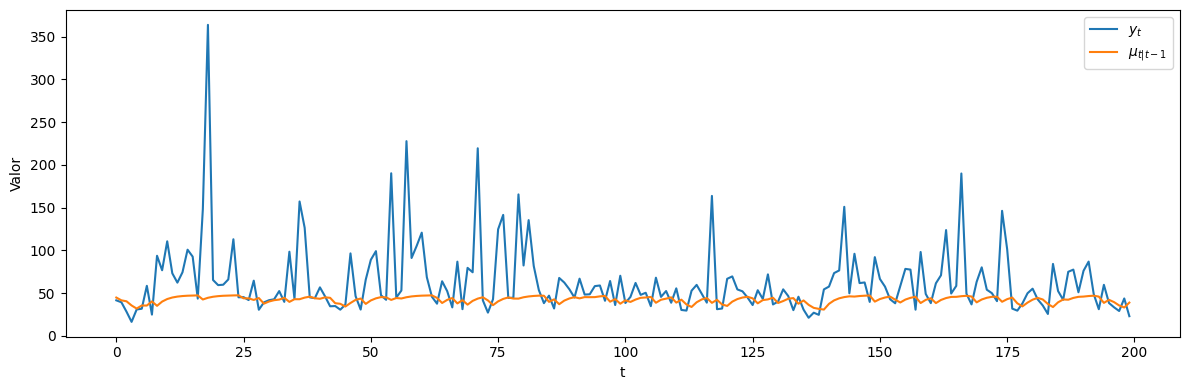

In [106]:
plt.figure(figsize=(12, 4))
plt.plot(y, label=r"$y_t$")
plt.plot(mu_filtered, label=r"$\mu_{t|t-1}$")
plt.xlabel("t")
plt.ylabel("Valor")
# plt.ylim(top=50)
plt.legend()
plt.tight_layout()
plt.show()

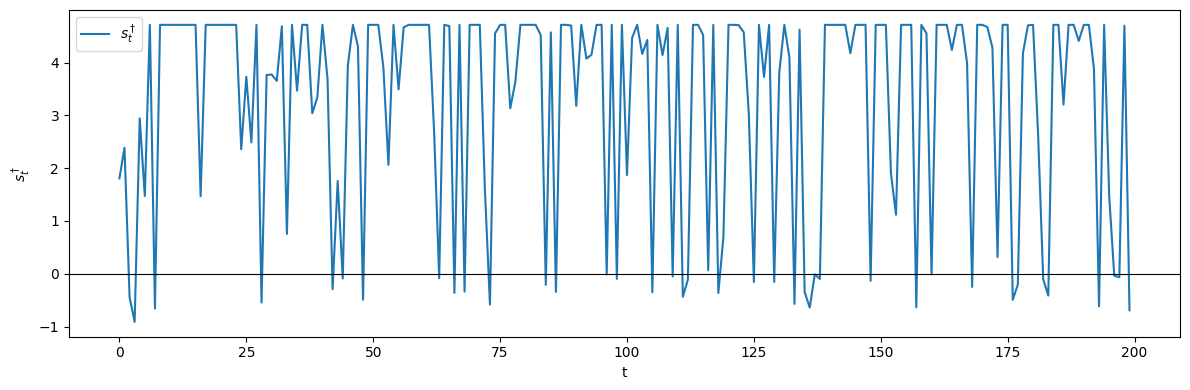

In [107]:
plt.figure(figsize=(12, 4))
plt.plot(s, label=r"$s_t^\dagger$")
plt.axhline(0, linewidth=0.8, c='black')
plt.xlabel("t")
plt.ylabel(r"$s_t^\dagger$")
plt.legend()
plt.tight_layout()
plt.show()

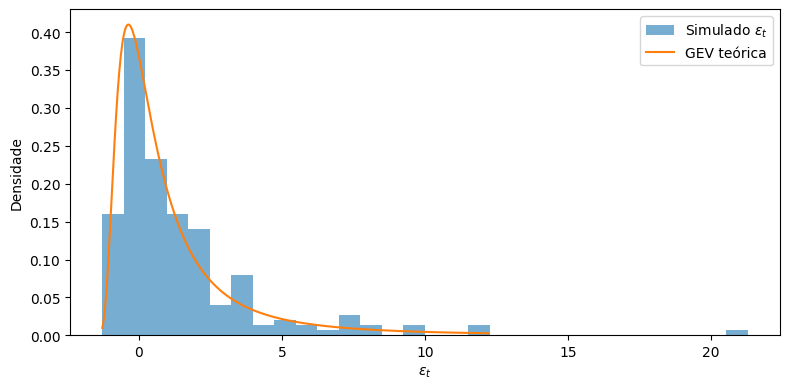

In [108]:
x_grid = np.linspace(
    np.min(epsilon),
    np.percentile(epsilon, 99.5),
    500
)

pdf = genextreme.pdf(
    x_grid,
    c=-xi,
    loc=0,
    scale=1
)

plt.figure(figsize=(8, 4))
plt.hist(
    epsilon,
    bins=30,
    density=True,
    alpha=0.6,
    label=r"Simulado $\varepsilon_t$"
)
plt.plot(
    x_grid,
    pdf,
    label="GEV teórica"
)
plt.xlabel(r"$\varepsilon_t$")
plt.ylabel("Densidade")
plt.legend()
plt.tight_layout()
plt.show()